## Mateus Ribeiro
### Códigos para o trabalho de Cadeias de Markov

In [1]:
import numpy as np
from matplotlib import pyplot as plt

### Cálculo das matrizes de transições com base na equação de chapman-kolmogorov

In [2]:
# Definindo a matriz de transição de 1 passo
P = np.array([[0.3, 0.2, 0.25, 0.25],
              [0.3, 0.4, 0.15, 0.15],
              [0.1, 0.2, 0.5, 0.2], 
              [0.1, 0.1, 0.1, 0.7]])

# Definindo uma lista para os valores desejados de "n"
ns = [1, 2, 5, 10, 20, 50, 100]

Ps = [np.linalg.matrix_power(P, n) for n in ns]

In [5]:
for key, item in zip(ns, Ps):
    print(f"Matriz de transição de {key} passos: \n {item}\n")

Matriz de transição de 1 passos: 
 [[0.3  0.2  0.25 0.25]
 [0.3  0.4  0.15 0.15]
 [0.1  0.2  0.5  0.2 ]
 [0.1  0.1  0.1  0.7 ]]

Matriz de transição de 2 passos: 
 [[0.2   0.215 0.255 0.33 ]
 [0.24  0.265 0.225 0.27 ]
 [0.16  0.22  0.325 0.295]
 [0.14  0.15  0.16  0.55 ]]

Matriz de transição de 5 passos: 
 [[0.176835   0.2030375  0.23108875 0.38903875]
 [0.179445   0.2058025  0.23326125 0.38149125]
 [0.17731    0.2046575  0.2343875  0.383645  ]
 [0.17083    0.19387    0.2181475  0.4171525 ]]

Matriz de transição de 10 passos: 
 [[0.17513852 0.20040675 0.22725751 0.39719723]
 [0.17519209 0.20048711 0.22736835 0.39695245]
 [0.1751767  0.20046602 0.22734171 0.39701557]
 [0.17493962 0.2001027  0.22683107 0.3981266 ]]

Matriz de transição de 20 passos: 
 [[0.17507893 0.20031556 0.22712948 0.39747604]
 [0.17507899 0.20031564 0.2271296  0.39747577]
 [0.17507897 0.20031562 0.22712957 0.39747584]
 [0.17507871 0.20031522 0.22712901 0.39747705]]

Matriz de transição de 50 passos: 
 [[0.17507886 

### Definindo uma função que calcula a diferença entre as matrizes dos $n's$ consecutivos e a soma do quadrado da diferença entre cada elemento da matriz de diferenças para se ter uma noção "unitária" de convergência

#### Ex:

Diff = $P(100) - P(50)$

udiff = $\sum_i \sum_j (p_{ij} (100) - p_{ij} (50))^2$

In [7]:
from typing import List, Tuple

def calcular_diffs(Ps: List[np.ndarray]) -> Tuple[List[np.ndarray], List[float]]:
    # Lista para armazenar as matrizes de diferenca
    diffs = []
    for i in range(1, len(Ps)):
        diff = Ps[i] - Ps[i-1]
        diffs.append(diff)

    # Lista para armazenar a soma do quadrado dos elementos 
    # das matrizes de diferenca
    diffs_unitaria = [np.sum(mat**2) for mat in diffs]

    return diffs, diffs_unitaria

In [8]:
diffs, udiffs = calcular_diffs(Ps)

#### Printando a diferença entre as matrizes para ver a convergência

In [13]:
for prev, curr, diff in zip(ns[:-1], ns[1:], diffs):
    print(f'Matriz de diferença entre a matriz de {prev} passos e a de {curr} passos: \n {diff}\n')

Matriz de diferença entre a matriz de 1 passos e a de 2 passos: 
 [[-0.1    0.015  0.005  0.08 ]
 [-0.06  -0.135  0.075  0.12 ]
 [ 0.06   0.02  -0.175  0.095]
 [ 0.04   0.05   0.06  -0.15 ]]

Matriz de diferença entre a matriz de 2 passos e a de 5 passos: 
 [[-0.023165   -0.0119625  -0.02391125  0.05903875]
 [-0.060555   -0.0591975   0.00826125  0.11149125]
 [ 0.01731    -0.0153425  -0.0906125   0.088645  ]
 [ 0.03083     0.04387     0.0581475  -0.1328475 ]]

Matriz de diferença entre a matriz de 5 passos e a de 10 passos: 
 [[-0.00169648 -0.00263075 -0.00383124  0.00815848]
 [-0.00425291 -0.00531539 -0.0058929   0.0154612 ]
 [-0.0021333  -0.00419148 -0.00704579  0.01337057]
 [ 0.00410962  0.0062327   0.00868357 -0.0190259 ]]

Matriz de diferença entre a matriz de 10 passos e a de 20 passos: 
 [[-5.95876847e-05 -9.11925130e-05 -1.28027785e-04  2.78807983e-04]
 [-1.13101787e-04 -1.71461444e-04 -2.38752745e-04  5.23315976e-04]
 [-9.77297379e-05 -1.50398005e-04 -2.12139729e-04  4.60267472

#### Pritando a diferença "unitária" entre as matrizes 

In [19]:
for prev, curr, diff in zip(ns[:-1], ns[1:], udiffs):
    print(f'diferença "unitaria" entre a matriz de {prev} passos e a de {curr} passos: {diff}\n')

diferença "unitaria" entre a matriz de 1 passos e a de 2 passos: 0.13235

diferença "unitaria" entre a matriz de 2 passos e a de 5 passos: 0.06491508501874999

diferença "unitaria" entre a matriz de 5 passos e a de 10 passos: 0.0011548132590276214

diferença "unitaria" entre a matriz de 10 passos e a de 20 passos: 1.3432642158061842e-06

diferença "unitaria" entre a matriz de 20 passos e a de 50 passos: 1.6076661553334786e-12

diferença "unitaria" entre a matriz de 50 passos e a de 100 passos: 2.7463761006961983e-30



#### Plotando dos valores das $udiffs$ para visualizar a convergência

Text(0, 0.5, 'Soma dos Quadrados')

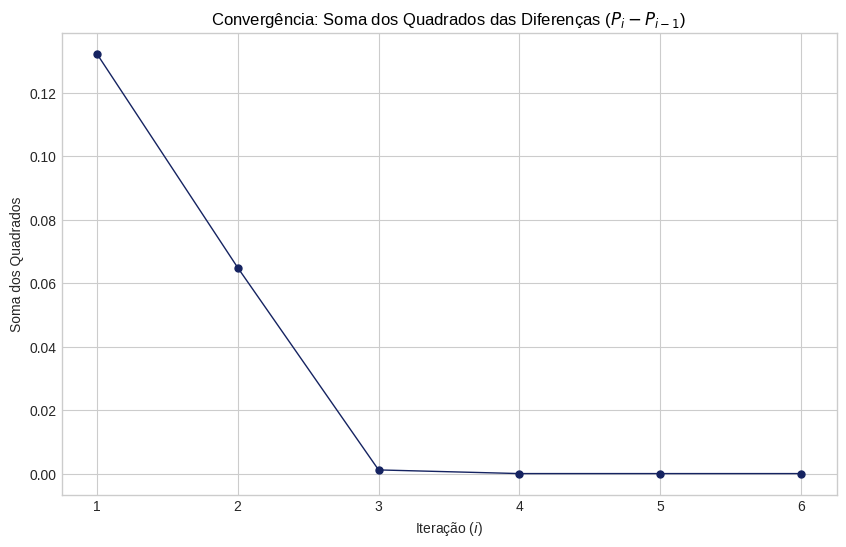

In [ ]:
# Definindo os xs para utilizar no plot
xs = np.arange(1, len(udiffs) + 1)
plt.figure(figsize=(10, 6)) 

plt.plot(xs, udiffs, 
         marker='o',          
         markersize=5,        
         linestyle='-',       
         linewidth=1,         
         color="#152361",     
         alpha=1.0)          

plt.title(r'Convergência: Soma dos Quadrados das Diferenças ($P_i - P_{i-1}$)', 
          color="#000000")

plt.xlabel('Iteração ($i$)')
plt.ylabel('Soma dos Quadrados')

### Para avaliar o quão rápido o sistema "esquece" as probabilidades iniciais e converge para as estacionárias, iremos utilizar como base a seguinte relação

$p(n) = p(0) P(n) = p(0) P^n$

In [44]:
# Definindo o vetor de probabilidades iniciais descritos na questao
p0 = np.array([0.3, 0.2, 0.1, 0.4])
powers = np.arange(1, 50, 1)

# Definindo as matrizes de transicao de 1 a 100 passos
Ps = [np.linalg.matrix_power(P, power) for power in powers]

ps = [np.dot(p0, Pi) for Pi in Ps]

In [45]:
Es = [p[0] for p in ps]
Rs = [p[1] for p in ps]
Ls = [p[2] for p in ps]
As = [p[3] for p in ps]

### Plotando os valores das probabilidades ao longo dos passos para observar a convergência para os valores estacionários

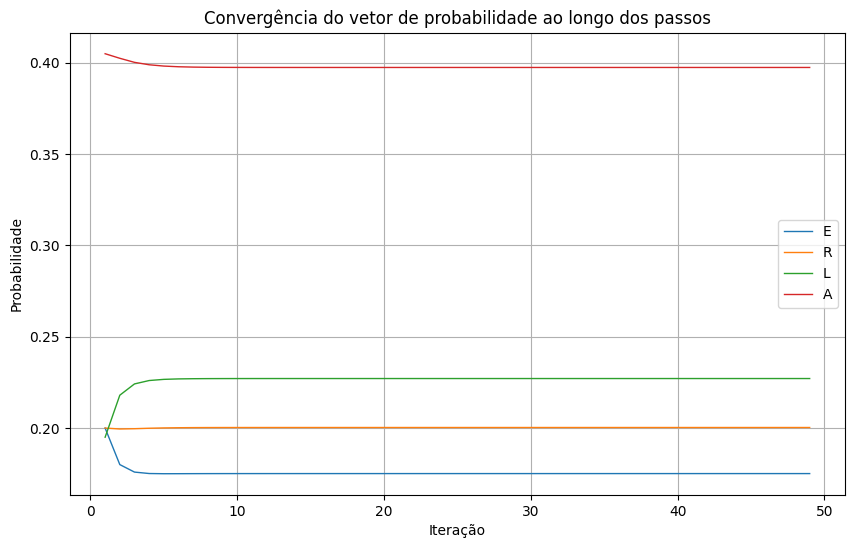

<Figure size 640x480 with 0 Axes>

In [49]:
plt.figure(figsize=(10, 6)) 
plt.plot(powers, Es, label = 'E', linewidth = 1)
plt.plot(powers, Rs, label = 'R', linewidth = 1)
plt.plot(powers, Ls, label = 'L', linewidth = 1)
plt.plot(powers, As, label = 'A', linewidth = 1)

plt.title(r'Convergência do vetor de probabilidade ao longo dos passos', 
          color="#000000")

plt.xlabel("Iteração")
plt.ylabel("Probabilidade")
plt.grid(True)
plt.legend()
plt.show()
plt.tight_layout()